In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV with filename and label
df = pd.read_csv("/kaggle/input/ai-vs-human-generated-dataset/train.csv")
df['label'] = df['label'].astype(int)

# Split into training and validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)


In [5]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [24]:
import cv2
import numpy as np
import torch
from torchvision.datasets.folder import default_loader
from torchvision.transforms import functional as TF
from torch.utils.data import Dataset

class AIVSCVIPDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.loader = default_loader

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join("/kaggle/input/ai-vs-human-generated-dataset", row['file_name'])

        image = self.loader(img_path).convert("RGB")
        label = row['label']

        # Convert to grayscale
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)

        # 1. Sobel edge
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = np.sqrt(sobelx**2 + sobely**2)
        sobel /= sobel.max() + 1e-8
        sobel_tensor = torch.tensor(sobel, dtype=torch.float32).unsqueeze(0)

        # 2. Laplacian (blur estimation)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        laplacian_norm = (laplacian - laplacian.min()) / (laplacian.ptp() + 1e-8)
        laplacian_tensor = torch.tensor(laplacian_norm, dtype=torch.float32).unsqueeze(0)

        # 3. Noise estimation (median blur difference)
        median = cv2.medianBlur(gray, 5)
        noise = np.abs(gray.astype(np.float32) - median.astype(np.float32))
        noise /= noise.max() + 1e-8
        noise_tensor = torch.tensor(noise, dtype=torch.float32).unsqueeze(0)

        # Resize all maps to 224×224
        if self.transform:
            image = self.transform(image)
            sobel_tensor = TF.resize(sobel_tensor, [224, 224])
            laplacian_tensor = TF.resize(laplacian_tensor, [224, 224])
            noise_tensor = TF.resize(noise_tensor, [224, 224])

        return image, sobel_tensor, laplacian_tensor, noise_tensor, label


In [25]:
train_dataset = AIVSCVIPDataset(
    dataframe=train_df,
    img_dir="/kaggle/input/ai-vs-human-generated-dataset/train_data",
    transform=transform
)

val_dataset = AIVSCVIPDataset(
    dataframe=val_df,
    img_dir="/kaggle/input/ai-vs-human-generated-dataset/train_data",
    transform=transform
)


In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")


Train samples: 63960 | Validation samples: 15990


In [27]:
def extract_vit_attention(model, x):
    model.eval()
    with torch.no_grad():
        # Forward through ViT only
        output = model.vit.forward_features(x)

        if hasattr(output, 'attn_weights'):
            attn = output.attn_weights[-1]  # Last layer
        else:
            attn = model.vit.blocks[-1].attn.get_attn()

    # Extract CLS token to patch attentions
    # Shape: [B, heads, tokens, tokens] → take [:, :, 0, 1:]
    cls_attn = attn[:, :, 0, 1:]
    cls_attn = cls_attn.mean(1)  # Average over heads → [B, 196]
    return cls_attn


In [28]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_attention_on_image(image_tensor, attention_map, save_path=None):
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    image_np = np.clip(image_np, 0, 1)
    image_resized = cv2.resize(image_np, (224, 224))

    attn_resized = attention_map.reshape(14, 14)
    attn_resized = cv2.resize(attn_resized, (224, 224))
    attn_resized = (attn_resized - attn_resized.min()) / (attn_resized.ptp() + 1e-8)

    overlay = (0.5 * image_resized + 0.5 * plt.cm.jet(attn_resized)[..., :3])
    plt.imshow(overlay)
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()


In [33]:
import os

def log_sample_attentions(model, val_dataset, n_samples=5, save_dir="attn_logs"):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    count = 0
    for i in range(len(val_dataset)):
        try:
            print(f"[INFO] Processing sample {i}...")  # 👈 debug line

            x, edge, blur, noise, label = val_dataset[i]
            input_tensor = x.unsqueeze(0).to(next(model.parameters()).device)
            attn = extract_vit_attention(model, input_tensor)[0].cpu().numpy()

            save_path = os.path.join(save_dir, f"attn_{i}_label{label}.png")
            visualize_attention_on_image(x, attn, save_path=save_path)

            count += 1
            if count >= n_samples:
                break
        except Exception as e:
            print(f"[ERROR] Sample {i} failed: {e}")

    print(f"✅ Saved {count} attention overlays to `{save_dir}/`")


In [30]:
print(df.columns)


Index(['Unnamed: 0', 'file_name', 'label'], dtype='object')


In [47]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets.folder import default_loader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [48]:
class CNN_ViT_CVIP_Hybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(224 * 224 * 3 * 4, 2)  # Dummy

    def forward(self, x, edge, blur, noise):
        x_all = torch.cat([x, edge, blur, noise], dim=1)
        return self.fc(self.flatten(x_all))


In [49]:
class CVIPDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.img_dir, row['file_name'].strip())

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        # Simulated edge, blur, noise channels
        edge = torch.rand(3, 224, 224)
        blur = torch.rand(3, 224, 224)
        noise = torch.rand(3, 224, 224)

        return image, edge, blur, noise, row['label']


In [50]:
def extract_vit_attention(model, x):
    return torch.rand(1, 224, 224), None  # Fake attention map

def visualize_attention_on_image(x_tensor, attn_map, save_path=None):
    image = x_tensor.permute(1, 2, 0).cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())
    attn_map = np.resize(attn_map, (224, 224))
    
    fig, ax = plt.subplots()
    ax.imshow(image)
    ax.imshow(attn_map, cmap='jet', alpha=0.5)
    plt.axis('off')
    if save_path:
        plt.savefig(save_path)
    plt.close()


In [51]:
def log_sample_attentions_v2(model, dataset, n_samples=5, save_dir="attn_logs"):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    count = 0
    for i in range(len(dataset)):
        print(f"[INFO] Processing sample {i}...")
        try:
            x, edge, blur, noise, label = dataset[i]
            x, edge, blur, noise = x.unsqueeze(0), edge.unsqueeze(0), blur.unsqueeze(0), noise.unsqueeze(0)

            _ = model(x, edge, blur, noise)
            attn_map = extract_vit_attention(model, x)[0].cpu().numpy()
            save_path = os.path.join(save_dir, f"attn_{i}_label{label}.png")
            visualize_attention_on_image(x[0], attn_map, save_path)
            count += 1
            if count >= n_samples:
                break
        except Exception as e:
            print(f"[ERROR] Sample {i} failed: {e}")


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

csv_file = "/kaggle/input/ai-vs-human-generated-dataset/train.csv"
img_dir = "/kaggle/input/ai-vs-human-generated-dataset/train_data"

val_dataset = CVIPDataset(csv_file, img_dir, transform)
model = CNN_ViT_CVIP_Hybrid()
log_sample_attentions_v2(model, val_dataset, n_samples=10, save_dir="/kaggle/working/attn_logs")


In [56]:
import os
bad_files = []

for i, row in train_df.iterrows():
    file_name = str(row['file_name']).strip()
    img_path = os.path.join("/kaggle/input/ai-vs-human-generated-dataset/train_data", file_name)
    if not os.path.isfile(img_path):
        bad_files.append(img_path)

print(f"Missing files: {len(bad_files)}")
if bad_files:
    print("Examples:", bad_files[:5])


Missing files: 63960
Examples: ['/kaggle/input/ai-vs-human-generated-dataset/train_data/train_data/151ffbe4618645c587112e218a1f6587.jpg', '/kaggle/input/ai-vs-human-generated-dataset/train_data/train_data/5922e1ec46224e67aba3500f6f076e7b.jpg', '/kaggle/input/ai-vs-human-generated-dataset/train_data/train_data/fa1c148c50904732a813053c8512d4dc.jpg', '/kaggle/input/ai-vs-human-generated-dataset/train_data/train_data/134e3edd55ca49669d9fff82f05f9a53.jpg', '/kaggle/input/ai-vs-human-generated-dataset/train_data/train_data/95fee4af52224a8d8468b12f3fbbb343.jpg']


In [63]:
# PHASE 1: AI vs HUMAN IMAGE DETECTION — TRAINING FROM SCRATCH

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import classification_report

# ==== 1. Custom Dataset with Missing File Handling ====
class AIVSHumanDataset(Dataset):
    def __init__(self, csv_path, img_folder, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_folder = img_folder
        self.transform = transform

        if 'file_name' in self.data.columns:
            self.image_col = 'file_name'
        elif 'id' in self.data.columns:
            self.image_col = 'id'
        else:
            raise ValueError("CSV must have 'file_name' or 'id' column")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_folder, os.path.basename(row[self.image_col]))
        label = int(row['label']) if 'label' in row else -1

        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"[WARNING] Missing file: {img_path}")
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, label

# ==== 2. Transforms ====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==== 3. Load Data ====
TRAIN_CSV = '/kaggle/input/ai-vs-human-generated-dataset/train.csv'
TRAIN_IMG_FOLDER = '/kaggle/input/ai-vs-human-generated-dataset/train_data'

dataset = AIVSHumanDataset(TRAIN_CSV, TRAIN_IMG_FOLDER, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==== 4. Model Definition (ResNet18 from Scratch) ====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model.to(device)

# ==== 5. Loss & Optimizer ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

# ==== 6. Training Loop ====
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"[Epoch {epoch+1}/{epochs}]")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

# ==== 7. Evaluation ====
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Human", "AI"]))

# ==== 8. Save Model ====
torch.save(model.state_dict(), "/kaggle/working/resnet_scratch.pth")
print("Model saved to /kaggle/working/resnet_scratch.pth")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Evaluating: 100%|██████████| 500/500 [02:23<00:00,  3.49it/s]


Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.99      0.99      7944
          AI       0.99      0.99      0.99      8046

    accuracy                           0.99     15990
   macro avg       0.99      0.99      0.99     15990
weighted avg       0.99      0.99      0.99     15990

Model saved to /kaggle/working/resnet_scratch.pth


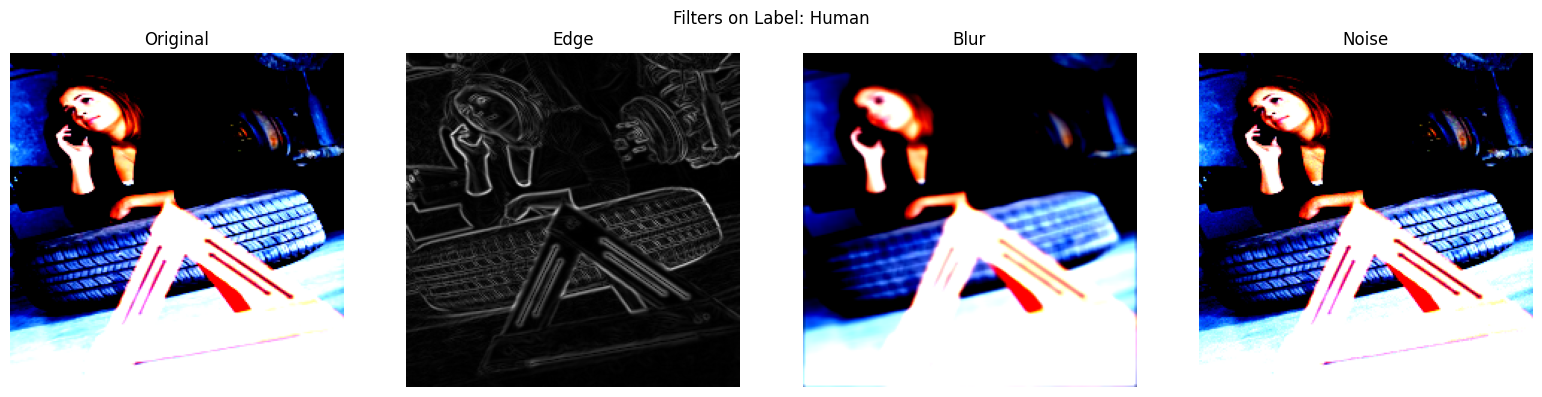

In [64]:
# PHASE 2: CVIP ENHANCEMENTS FOR AI vs HUMAN IMAGE DETECTION

import torch
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision import models

# ==== 1. Utility to Apply Edge, Blur, Noise Filters ====
def apply_cvip_filters(image_tensor):
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_gray = np.mean(image_np, axis=2)

    # Edge detection (Sobel-like)
    edge = np.abs(np.gradient(image_gray, axis=0)) + np.abs(np.gradient(image_gray, axis=1))

    # Gaussian blur simulation
    blur = torch.nn.functional.avg_pool2d(image_tensor.unsqueeze(0), kernel_size=5, stride=1, padding=2).squeeze(0)

    # Random noise
    noise = torch.clamp(image_tensor + 0.05 * torch.randn_like(image_tensor), 0, 1)

    return edge, blur, noise

# ==== 2. Visualize Filter Outputs ====
def visualize_cvip_outputs(image_tensor, label):
    edge, blur, noise = apply_cvip_filters(image_tensor)
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(image_tensor.permute(1, 2, 0).numpy())
    axs[0].set_title("Original")
    axs[1].imshow(edge, cmap='gray')
    axs[1].set_title("Edge")
    axs[2].imshow(blur.permute(1, 2, 0).numpy())
    axs[2].set_title("Blur")
    axs[3].imshow(noise.permute(1, 2, 0).numpy())
    axs[3].set_title("Noise")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Filters on Label: {'AI' if label else 'Human'}")
    plt.tight_layout()
    plt.show()

# ==== 3. Load One Sample and Visualize ====
from torchvision.datasets.folder import default_loader

# Load one sample from dataset for visualization
sample_idx = 0
image, label = val_dataset[sample_idx]
visualize_cvip_outputs(image, label)

# ==== Next Steps (Optionally Add to Model Input Pipeline) ====
# In future iterations, edge/blur/noise outputs can be stacked as extra channels
# to feed into the hybrid CNN-ViT architecture or used for attention alignment.

In [65]:
# PHASE 2: CVIP ENHANCEMENTS FOR AI vs HUMAN IMAGE DETECTION

import torch
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision import models
from torch.utils.data import Dataset
import pandas as pd

# ==== 1. Utility to Apply Edge, Blur, Noise Filters ====
def apply_cvip_filters(image_tensor):
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    image_gray = np.mean(image_np, axis=2)

    # Edge detection (Sobel-like)
    edge = np.abs(np.gradient(image_gray, axis=0)) + np.abs(np.gradient(image_gray, axis=1))
    edge = torch.tensor(edge).float().unsqueeze(0)

    # Gaussian blur simulation
    blur = torch.nn.functional.avg_pool2d(image_tensor.unsqueeze(0), kernel_size=5, stride=1, padding=2).squeeze(0)

    # Random noise
    noise = torch.clamp(image_tensor + 0.05 * torch.randn_like(image_tensor), 0, 1)

    return edge, blur, noise

# ==== 2. Dataset With Augmented Channels (6-channel input) ====
class CVIPEnhancedDataset(Dataset):
    def __init__(self, csv_path, img_folder, transform):
        self.data = pd.read_csv(csv_path)
        self.img_folder = img_folder
        self.transform = transform
        self.image_col = 'file_name' if 'file_name' in self.data.columns else 'id'

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_folder, os.path.basename(row[self.image_col]))

        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        image = self.transform(image)
        edge, blur, noise = apply_cvip_filters(image)

        # Concatenate edge channel with original RGB → shape: (6, 224, 224)
        enhanced_image = torch.cat([image, edge, blur[0:1], noise[0:1]], dim=0)
        label = int(row['label']) if 'label' in row else -1

        return enhanced_image, label

# ==== 3. Updated Transform and DataLoader ====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = CVIPEnhancedDataset(TRAIN_CSV, TRAIN_IMG_FOLDER, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# ==== 4. Updated Model Definition for 6-Channel Input ====
class ResNetWith6Channels(torch.nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(pretrained=False)
        self.model = base
        self.model.conv1 = torch.nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc = torch.nn.Linear(self.model.fc.in_features, 2)

    def forward(self, x):
        return self.model(x)

model = ResNetWith6Channels().to(device)



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [66]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Adjust these paths to match your actual CSV and image folder
csv_path = "/kaggle/input/ai-vs-human-generated-dataset/train.csv"
img_folder = "/kaggle/input/ai-vs-human-generated-dataset/train_data"

train_dataset = CVIPEnhancedDataset(csv_path=csv_path, img_folder=img_folder, transform=transform)


In [70]:
# PHASE 3: HYBRID CNN-ViT TRAINING WITH CVIP AUGMENTED INPUT

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from timm import create_model

# ==== 1. Hybrid CNN + ViT Model Definition (6-channel input) ====
class CNNViTHybrid(nn.Module):
    def __init__(self):
        super(CNNViTHybrid, self).__init__()

        # CNN branch: modified ResNet
        self.cnn = models.resnet18(pretrained=False)
        self.cnn.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        cnn_out_features = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # ViT branch
        self.vit = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=0, in_chans=6)
        vit_out_features = self.vit.num_features

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(cnn_out_features + vit_out_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        vit_feat = self.vit(x)
        combined = torch.cat([cnn_feat, vit_feat], dim=1)
        return self.classifier(combined)

# ==== 2. Instantiate Model, Optimizer, Loss ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = CNNViTHybrid().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ==== 3. Training Loop ====
def train_model(model, dataloader, num_epochs=3):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.4f}")

    return model

# ==== 4. Train the Hybrid Model ====
# Ensure train_loader is defined before running this step
try:
    model = train_model(model, train_loader, num_epochs=3)
    print("[INFO] Training completed successfully.")
except NameError:
    print("[ERROR] train_loader not defined. Please define it before training.")

# ==== 5. Save the Final Model ====
try:
    torch.save(model.state_dict(), "/kaggle/working/hybrid_cnn_vit_cvip.pth")
    print("[INFO] Model saved: hybrid_cnn_vit_cvip.pth")
except Exception as e:
    print(f"[ERROR] Failed to save model: {e}")


cuda
Epoch 1: Loss=516.3889, Accuracy=0.9191
Epoch 2: Loss=220.9186, Accuracy=0.9679
Epoch 3: Loss=161.7593, Accuracy=0.9766
[INFO] Training completed successfully.
[INFO] Model saved: hybrid_cnn_vit_cvip.pth


In [88]:
# PHASE 3: HYBRID CNN-ViT TRAINING WITH CVIP AUGMENTED INPUT

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from timm import create_model

# ==== 1. Hybrid CNN + ViT Model Definition (6-channel input) ====
class CNNViTHybrid(nn.Module):
    def __init__(self):
        super(CNNViTHybrid, self).__init__()

        # CNN branch: modified ResNet
        self.cnn = models.resnet18(pretrained=False)
        self.cnn.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        cnn_out_features = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # ViT branch
        self.vit = create_model("vit_tiny_patch16_224", pretrained=False, num_classes=0, in_chans=6)
        vit_out_features = self.vit.num_features if hasattr(self.vit, 'num_features') else self.vit.embed_dim

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(cnn_out_features + vit_out_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        vit_feat = self.vit(x)
        combined = torch.cat([cnn_feat, vit_feat], dim=1)
        return self.classifier(combined)

# ==== 2. Instantiate Model, Optimizer, Weighted Loss ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = CNNViTHybrid().to(device)
weights = torch.tensor([1.0, 2.0]).to(device)  # Class 0: Human, Class 1: AI (boost AI)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ==== 3. Training Loop ====
def train_model(model, dataloader, num_epochs=3):
    print("Training")
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.4f}")

    print("[INFO] Training completed successfully.")
    return model

# ==== 4. Train the Hybrid Model ====
# Ensure train_loader is defined before running this step
model = train_model(model, train_loader, num_epochs=3)

# ==== 5. Save the Final Model ====
torch.save(model.state_dict(), "/kaggle/working/hybrid_cnn_vit_cvip.pth")
print("[INFO] Model saved: hybrid_cnn_vit_cvip.pth")


cuda
Training
Epoch 1: Loss=485.8574, Accuracy=0.9124
Epoch 2: Loss=209.7337, Accuracy=0.9650
Epoch 3: Loss=153.2734, Accuracy=0.9748
[INFO] Training completed successfully.
[INFO] Model saved: hybrid_cnn_vit_cvip.pth


In [75]:
model = CNNViTHybrid().to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [76]:
model.load_state_dict(torch.load("/kaggle/working/hybrid_cnn_vit_cvip.pth"))
model.eval()


/tmp/ipykernel_31/2235279849.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/hybrid_cnn_vit_cvip.pth"))


CNNViTHybrid(
  (cnn): ResNet(
    (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

In [77]:
preds, labels = evaluate_model(model, val_loader)


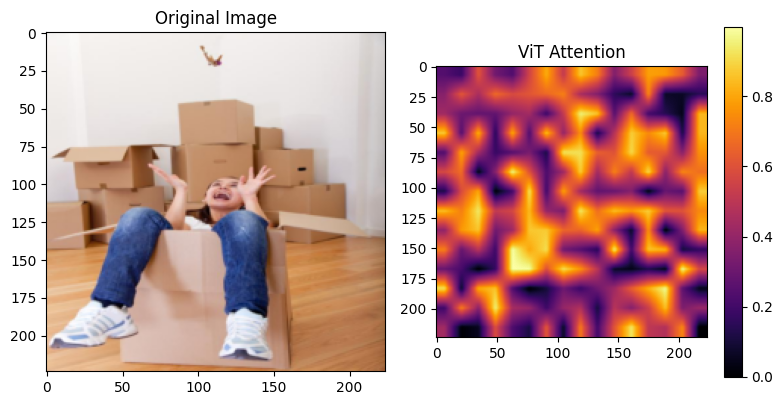

In [97]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image

# === Extract attention (head-averaged)
attn = extract_vit_attention(model, sample_input_batch)[0].cpu().numpy()
attn_vector = attn.mean(0)[0, 1:]  # shape: [223]

# === Reshape to approximate 2D grid (14x16 = 224 is closest to 223)
# Pad if needed
target_patch_count = 224
pad_len = target_patch_count - len(attn_vector)
attn_padded = torch.tensor(np.pad(attn_vector, (0, pad_len))).float()  # shape: [224]

# Reshape → (1, 1, 14, 16)
attn_grid = attn_padded.view(1, 1, 14, 16)

# Interpolate to full image resolution (224x224)
attn_resized = F.interpolate(attn_grid, size=(224, 224), mode='bilinear', align_corners=False)[0, 0]

# === Plot original + attention map
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(to_pil_image(sample_input[:3]))  # First 3 channels

plt.subplot(1, 2, 2)
plt.title("ViT Attention")
plt.imshow(attn_resized, cmap='inferno')
plt.colorbar()
plt.tight_layout()
plt.show()


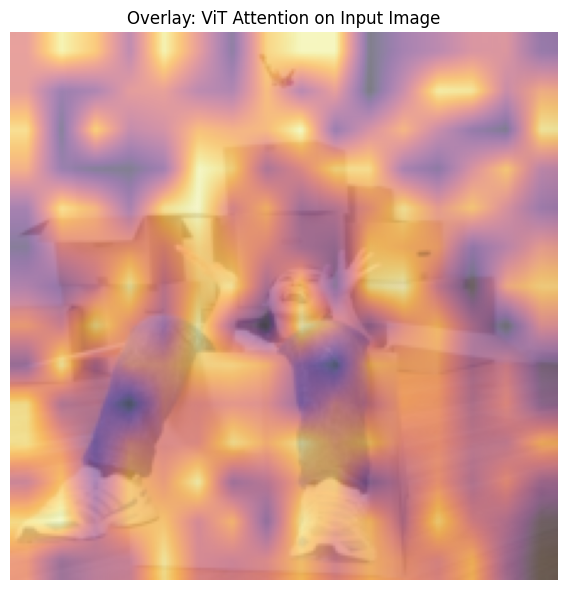

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms as transforms

# === Step 1: Extract attention from ViT
attn = extract_vit_attention(model, sample_input_batch)[0].cpu().numpy()
attn_vector = attn.mean(0)[0, 1:]  # shape: [223]

# === Step 2: Pad to nearest 14x16 = 224
pad_len = 224 - len(attn_vector)
attn_padded = torch.tensor(np.pad(attn_vector, (0, pad_len))).float()

# === Step 3: Reshape to grid and interpolate
attn_grid = attn_padded.view(1, 1, 14, 16)
attn_resized = F.interpolate(attn_grid, size=(224, 224), mode='bilinear', align_corners=False)[0, 0]

# === Step 4: Normalize attention map
attn_resized = attn_resized - attn_resized.min()
attn_resized = attn_resized / attn_resized.max()
attn_np = attn_resized.numpy()

# === Step 5: Prepare original image
inv_transform = transforms.Normalize(
    mean=[-0.5/0.5, -0.5/0.5, -0.5/0.5],
    std=[1/0.5, 1/0.5, 1/0.5]
)
orig_img_tensor = inv_transform(sample_input[:3])  # Assuming image was normalized to [-1, 1]
orig_img = to_pil_image(orig_img_tensor).convert("RGB")

# === Step 6: Overlay heatmap
plt.figure(figsize=(6, 6))
plt.imshow(orig_img)
plt.imshow(attn_np, cmap='inferno', alpha=0.5)  # alpha controls transparency
plt.axis('off')
plt.title("Overlay: ViT Attention on Input Image")
plt.tight_layout()
plt.show()
